# Este notebook analiza el **dataset estructurado completo generado por el Miner** para TanStack.

El archivo `results.json` integra evidencia de:

- **CodeQL**: hallazgos sobre código fuente.
- **Grype**: vulnerabilidades conocidas en dependencias.
- Metadatos de repositorios y referencias a SBOM generados con Syft.

El objetivo es analizar de manera conjunta y separada las distintas fuentes de evidencia, identificar patrones, concentraciones, severidades y diferencias entre repositorios, y dejar resultados estructurados para el Visualizer.



## 1. Importaciones

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown


## 2. Carga de `results.json`

In [2]:
import os

_env_results = os.environ.get("ANALYZER_RESULTS_JSON")

candidates = []
if _env_results:
    candidates.append(Path(_env_results))

candidates += [
    Path("../../results.json"),
    Path("../results.json"),
    Path("results.json"),
    Path("../../results(1).json"),
    Path("../results(1).json"),
    Path("results(1).json"),
]

RESULTS_FILE = next((p for p in candidates if p.exists()), None)

if RESULTS_FILE is None:
    raise FileNotFoundError(
        "No se encontró results.json. Define ANALYZER_RESULTS_JSON o ajusta la lista 'candidates'."
    )

print("Archivo utilizado:", RESULTS_FILE.resolve())

with open(RESULTS_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)

Archivo utilizado: /workspaces/dev-container-test/deliverables/miner/results.json


## 3. Resumen general de la ejecución

In [3]:
summary = data["summary"]

for key, value in summary.items():
    print(f"{key}: {value}")


organization: TanStack
total_repositories: 30
analyzed_repositories: 29
failed_repositories: 0
sbom_failed_repositories: 0
unsupported_repositories: 1
total_findings: 7361
grype_failed_repositories: 0
grype_skipped_repositories: 0
total_vulnerabilities: 5186


Este resumen corresponde a la ejecución completa del Miner. El campo `total_findings` representa el total integrado de hallazgos de todas las herramientas incluidas en el dataset.

## 4. Estado de los repositorios

In [4]:
repo_status = pd.DataFrame([
    {
        "repository": repo.get("name"),
        "status": repo.get("status"),
        "languages": ", ".join(repo.get("languages", []) or []),
        "analyzed_languages": ", ".join(repo.get("analyzed_languages", []) or []),
        "codeql_findings": len(repo.get("findings", []) or []),
        "error": repo.get("error"),
        "sbom_status": (repo.get("sbom") or {}).get("status"),
        "sbom_components": (repo.get("sbom") or {}).get("component_count"),
        "grype_status": (repo.get("grype") or {}).get("status"),
        "grype_vulnerabilities": (repo.get("grype") or {}).get("vulnerability_count"),
    }
    for repo in data.get("repositories", [])
])

repo_status


,repository,status,languages,analyzed_languages,codeql_findings,error,sbom_status,sbom_components,grype_status,grype_vulnerabilities
0,ai,analyzed,"CSS, JavaScript, Shell, Svelte, TypeScript, Vue",TypeScript,159,None,generated,3165,analyzed,273
1,alt-cli,analyzed,"CSS, JavaScript, TypeScript",TypeScript,9,None,generated,676,analyzed,179
2,bling,analyzed,TypeScript,TypeScript,29,None,generated,534,analyzed,108
3,charts,analyzed,"CSS, JavaScript, Svelte, TypeScript",TypeScript,130,None,generated,1196,analyzed,121
4,cli,analyzed,"CSS, EJS, JavaScript, Shell, TypeScript",TypeScript,68,None,generated,1767,analyzed,244
5,config,analyzed,"CSS, JavaScript, TypeScript, Vue",TypeScript,9,None,generated,654,analyzed,78
6,container,analyzed,"C, C++, CSS, Go, HTML, JavaScript, Svelte, Typ...",TypeScript,217,None,generated,2195,analyzed,37
7,db,analyzed,"Dockerfile, HTML, JavaScript, Python, Rust, Sv...","Python, TypeScript",84,None,generated,4373,analyzed,619
8,devtools,analyzed,"CSS, HTML, JavaScript, Svelte, TypeScript, Vue",TypeScript,14,None,generated,3172,analyzed,441
9,form,analyzed,"JavaScript, Svelte, TypeScript",TypeScript,263,None,generated,2712,analyzed,314


In [5]:
repo_status["status"].value_counts()


status
analyzed       29
unsupported     1
Name: count, dtype: int64

In [6]:
repo_status[
    ~repo_status["status"].isin(["analyzed", "unsupported"])
][["repository", "status", "error"]]


,repository,status,error


Los repositorios fallidos deben interpretarse como ejecuciones incompletas, no como repositorios sin hallazgos. Esta diferencia es importante para evitar sesgos en la comparación.

## 5. Dataset integrado de hallazgos

In [7]:
df_all = pd.DataFrame(data.get("findings", []))

print("Filas del dataset integrado:", len(df_all))
print("Columnas:", list(df_all.columns))
print("Dimensiones:", df_all.shape)

df_all.head()


Filas del dataset integrado: 7361
Columnas: ['repository', 'tool', 'vulnerability_type', 'severity', 'location', 'line', 'package', 'version', 'fixed_version', 'artifact_type', 'language', 'message']
Dimensiones: (7361, 12)


,repository,tool,vulnerability_type,severity,location,line,package,version,fixed_version,artifact_type,language,message
0,TanStack/ai,codeql,js/biased-cryptographic-random,warning,packages/ai-openrouter/src/pkce.ts,73.0,NaN,NaN,NaN,NaN,TypeScript,Using modulo on a [cryptographically secure ra...
1,TanStack/ai,codeql,js/comparison-between-incompatible-types,warning,examples/ts-react-native-chat/src/App.tsx,107.0,NaN,NaN,NaN,NaN,TypeScript,"Variable 'value' cannot be of type null, but i..."
2,TanStack/ai,codeql,js/comparison-between-incompatible-types,warning,testing/react-native-smoke/scripts/assert-impo...,177.0,NaN,NaN,NaN,NaN,TypeScript,Variable 'requestedNames' cannot be of type un...
3,TanStack/ai,codeql,js/file-system-race,warning,scripts/distribute-keys.ts,155.0,NaN,NaN,NaN,NaN,TypeScript,The file may have changed since it [was checke...
4,TanStack/ai,codeql,js/file-system-race,warning,testing/panel/src/routes/api.list-traces.ts,30.0,NaN,NaN,NaN,NaN,TypeScript,The file may have changed since it [was checke...


### Validación del total integrado

In [8]:
declared_total = data["summary"].get("total_findings")

print("Hallazgos en data['findings']:", len(df_all))
print("Hallazgos declarados por Miner:", declared_total)

assert len(df_all) == declared_total

print("\nDataset integrado cargado correctamente.")


Hallazgos en data['findings']: 7361
Hallazgos declarados por Miner: 7361

Dataset integrado cargado correctamente.


## 6. Distribución por herramienta

In [9]:
tool_counts = df_all["tool"].value_counts()

tool_percentages = (
    df_all["tool"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

tool_summary = pd.DataFrame({
    "cantidad": tool_counts,
    "porcentaje": tool_percentages
})

tool_summary


,cantidad,porcentaje
tool,,
grype,5186,70.45
codeql,2175,29.55


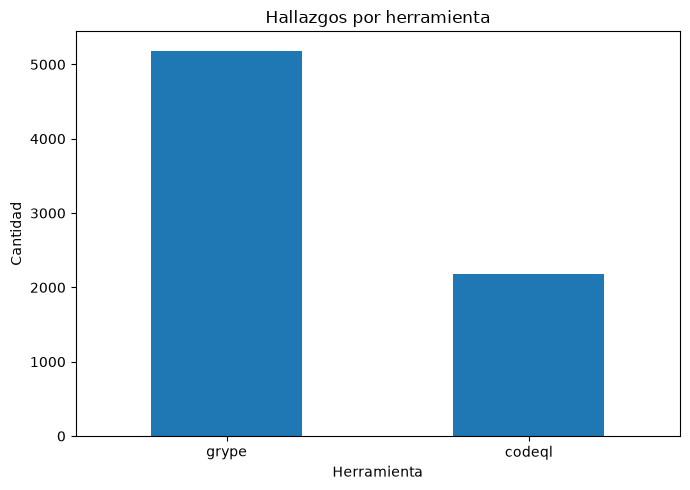

In [10]:
tool_counts.plot(kind="bar", figsize=(7, 5))

plt.title("Hallazgos por herramienta")
plt.xlabel("Herramienta")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Esta separación permite distinguir correctamente entre problemas detectados en el código fuente y vulnerabilidades conocidas en dependencias.

## 7. Separación de CodeQL y Grype

In [11]:
df_codeql = df_all[
    df_all["tool"].str.lower() == "codeql"
].copy()

df_grype = df_all[
    df_all["tool"].str.lower() == "grype"
].copy()

print("Hallazgos CodeQL:", len(df_codeql))
print("Vulnerabilidades Grype:", len(df_grype))
print("Total:", len(df_codeql) + len(df_grype))


Hallazgos CodeQL: 2175
Vulnerabilidades Grype: 5186
Total: 7361


## 8. Análisis CodeQL — severidad

In [12]:
codeql_severity = df_codeql["severity"].value_counts()

codeql_severity_pct = (
    df_codeql["severity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

pd.DataFrame({
    "cantidad": codeql_severity,
    "porcentaje": codeql_severity_pct
})


,cantidad,porcentaje
severity,,
note,1281,58.90
warning,785,36.09
error,109,5.01


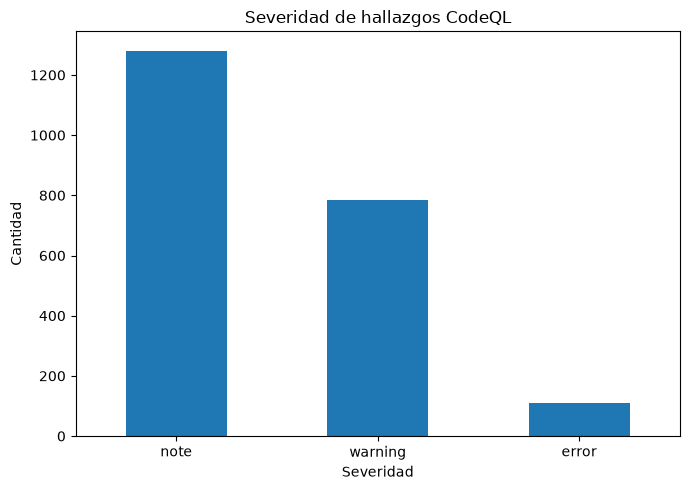

In [13]:
codeql_severity.plot(kind="bar", figsize=(7, 5))

plt.title("Severidad de hallazgos CodeQL")
plt.xlabel("Severidad")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. Análisis CodeQL — tipos de hallazgo

In [14]:
codeql_rules = df_codeql["vulnerability_type"].value_counts()

codeql_rules.head(20)


vulnerability_type
js/unused-local-variable                      1188
js/useless-assignment-to-local                 125
js/use-before-declaration                       82
js/syntax-error                                 72
js/trivial-conditional                          61
js/useless-expression                           59
js/insecure-temporary-file                      43
js/stack-trace-exposure                         42
js/superfluous-trailing-arguments               40
js/missing-origin-check                         39
js/unreachable-statement                        36
js/file-system-race                             35
js/polynomial-redos                             32
js/incomplete-multi-character-sanitization      24
js/bad-code-sanitization                        22
js/log-injection                                21
js/call-to-non-callable                         20
js/property-access-on-non-object                18
js/whitespace-contradicts-precedence            17
js/http-to-f

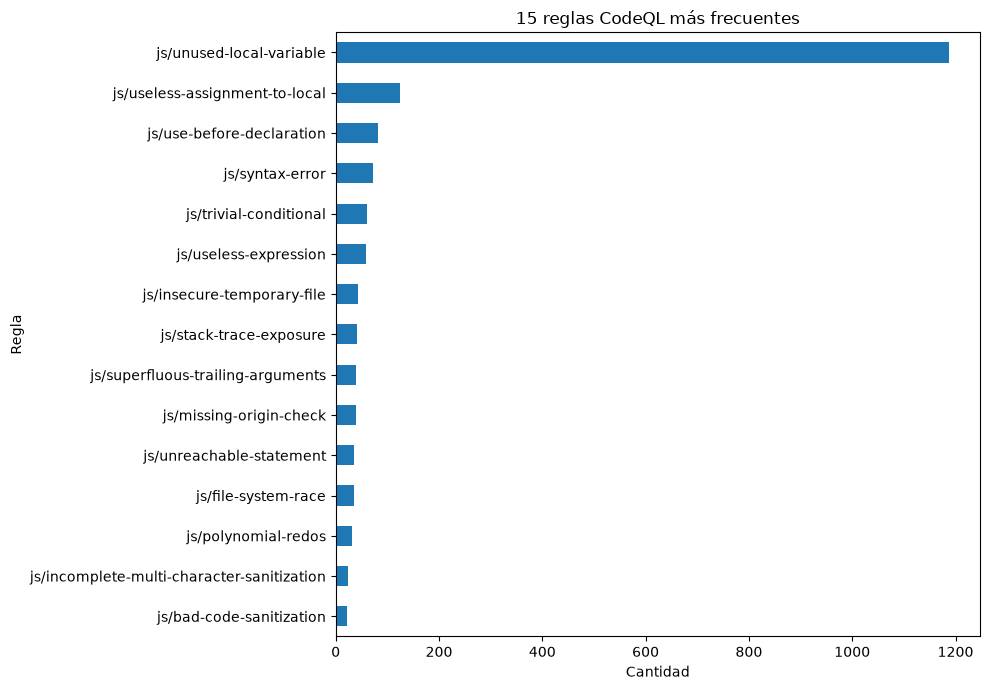

In [15]:
codeql_rules.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("15 reglas CodeQL más frecuentes")
plt.xlabel("Cantidad")
plt.ylabel("Regla")
plt.tight_layout()
plt.show()


## 10. CodeQL — distribución por repositorio

In [16]:
codeql_by_repo = df_codeql["repository"].value_counts()

codeql_by_repo.head(15)


repository
TanStack/router          660
TanStack/form            263
TanStack/container       217
TanStack/preact          164
TanStack/ai              159
TanStack/charts          130
TanStack/query           102
TanStack/table            98
TanStack/tanstack.com     86
TanStack/db               84
TanStack/cli              68
TanStack/bling            29
TanStack/intent           20
TanStack/redact           18
TanStack/devtools         14
Name: count, dtype: int64

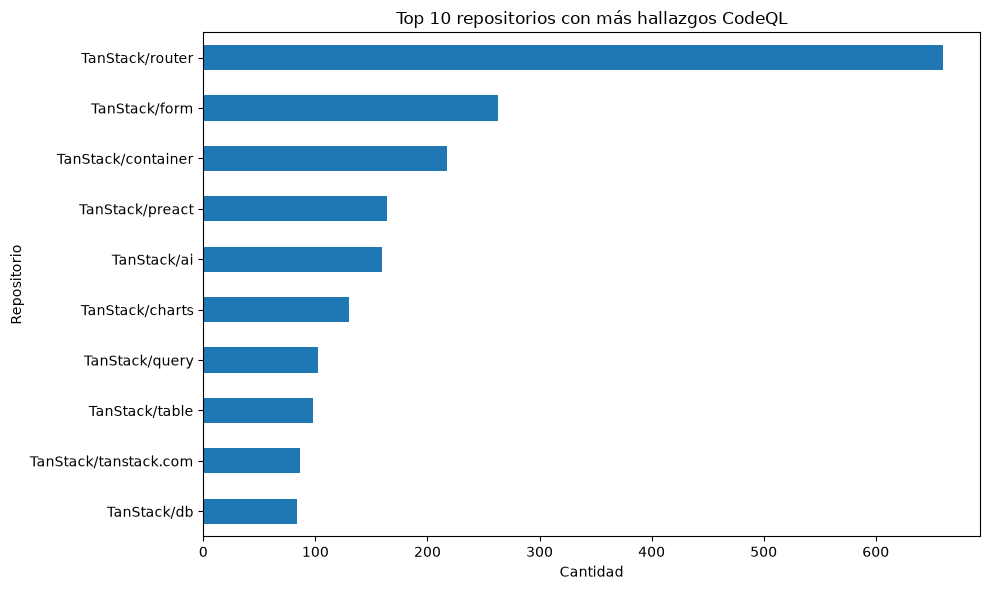

In [17]:
codeql_by_repo.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 repositorios con más hallazgos CodeQL")
plt.xlabel("Cantidad")
plt.ylabel("Repositorio")
plt.tight_layout()
plt.show()


## 11. CodeQL — archivos de prueba vs otros archivos

In [18]:
df_codeql["is_test"] = df_codeql["location"].str.contains(
    r"(?:^|/)(?:__tests__|__testfixtures__|test|tests|spec|specs|testing)(?:/|$)|(?:\.test\.|\.spec\.)",
    case=False,
    regex=True,
    na=False
)

test_counts = df_codeql["is_test"].value_counts()
test_pct = (
    df_codeql["is_test"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

pd.DataFrame({
    "cantidad": test_counts,
    "porcentaje": test_pct
}).rename(index={True: "Pruebas", False: "Otros archivos"})


,cantidad,porcentaje
is_test,,
Pruebas,1364,62.71
Otros archivos,811,37.29


Separar archivos de prueba evita interpretar suites de testing extensas como si fueran equivalentes al código utilizado en producción.

## 12. Grype — distribución por severidad

In [19]:
grype_severity = df_grype["severity"].value_counts()

grype_severity_pct = (
    df_grype["severity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

grype_severity_summary = pd.DataFrame({
    "cantidad": grype_severity,
    "porcentaje": grype_severity_pct
})

grype_severity_summary


,cantidad,porcentaje
severity,,
High,2395,46.18
Medium,2199,42.40
Low,409,7.89
Critical,183,3.53


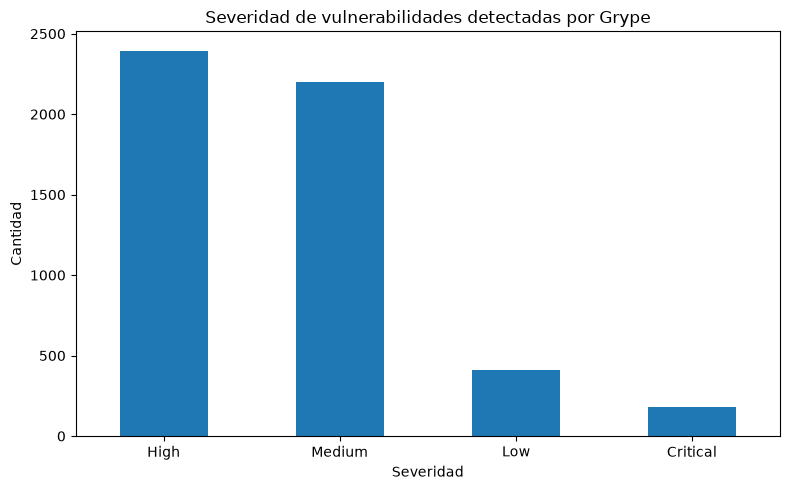

In [20]:
grype_severity.plot(kind="bar", figsize=(8, 5))

plt.title("Severidad de vulnerabilidades detectadas por Grype")
plt.xlabel("Severidad")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 13. Grype — identificadores de vulnerabilidad más frecuentes

In [21]:
grype_vuln_types = df_grype["vulnerability_type"].value_counts()

grype_vuln_types.head(20)


vulnerability_type
GHSA-6j4f-fj2g-mc7p    63
GHSA-q2hr-2g5m-vwhr    63
GHSA-qhr7-859c-m2p7    63
GHSA-rgw5-rvv9-x895    52
GHSA-23c5-xmqv-rm74    50
GHSA-3ppc-4f35-3m26    50
GHSA-7r86-cg39-jmmj    50
GHSA-mh99-v99m-4gvg    50
GHSA-3jxr-9vmj-r5cp    49
GHSA-2883-xcg3-v3hh    44
GHSA-5p4m-2wfm-xmqj    44
GHSA-fxqj-rqcc-2cmp    43
GHSA-52cp-r559-cp3m    42
GHSA-r28c-9q8g-f849    42
GHSA-h67p-54hq-rp68    40
GHSA-68fv-2mgg-jv7q    36
GHSA-82fw-gwwq-j7x9    36
GHSA-v6wh-96g9-6wx3    35
GHSA-r53p-7pc4-xj5r    34
GHSA-rfgv-xxqx-mfg5    33
Name: count, dtype: int64

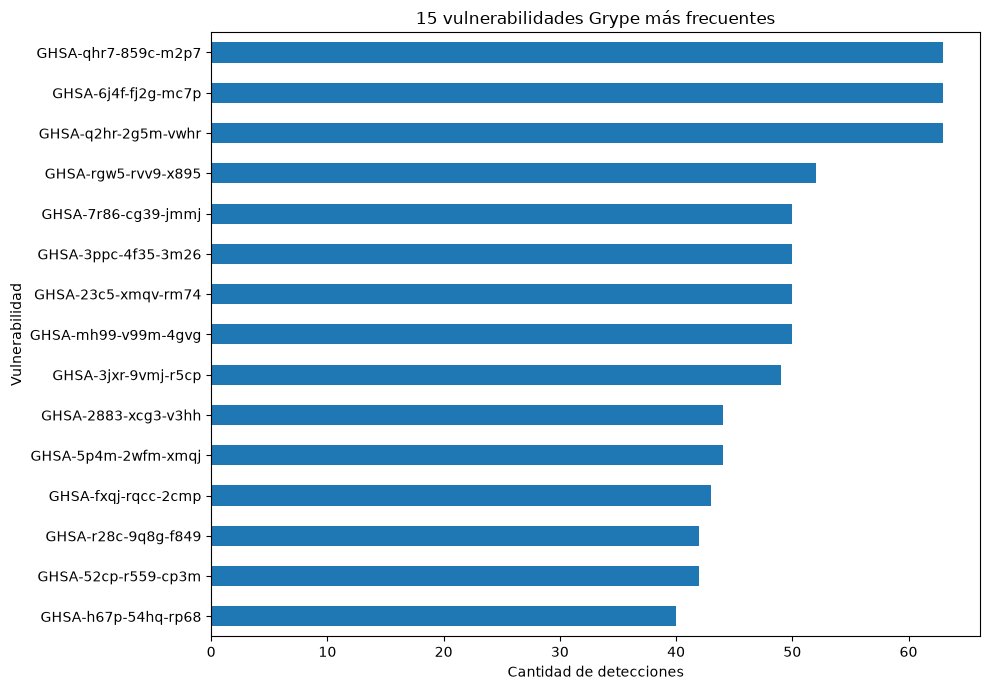

In [22]:
grype_vuln_types.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("15 vulnerabilidades Grype más frecuentes")
plt.xlabel("Cantidad de detecciones")
plt.ylabel("Vulnerabilidad")
plt.tight_layout()
plt.show()


Una detección no equivale necesariamente a una vulnerabilidad única. El mismo identificador puede aparecer en múltiples repositorios, paquetes o versiones.

## 14. Grype — paquetes más afectados

In [23]:
grype_packages = df_grype["package"].value_counts()

grype_packages.head(20)


package
undici             630
axios              484
brace-expansion    382
hono               275
js-yaml            186
postcss            168
minimatch          150
vite               127
next               124
fast-uri           121
@xmldom/xmldom     111
tar                104
devalue             85
seroval             83
nanoid              79
qs                  63
picomatch           60
lodash              58
node-forge          55
nx                  53
Name: count, dtype: int64

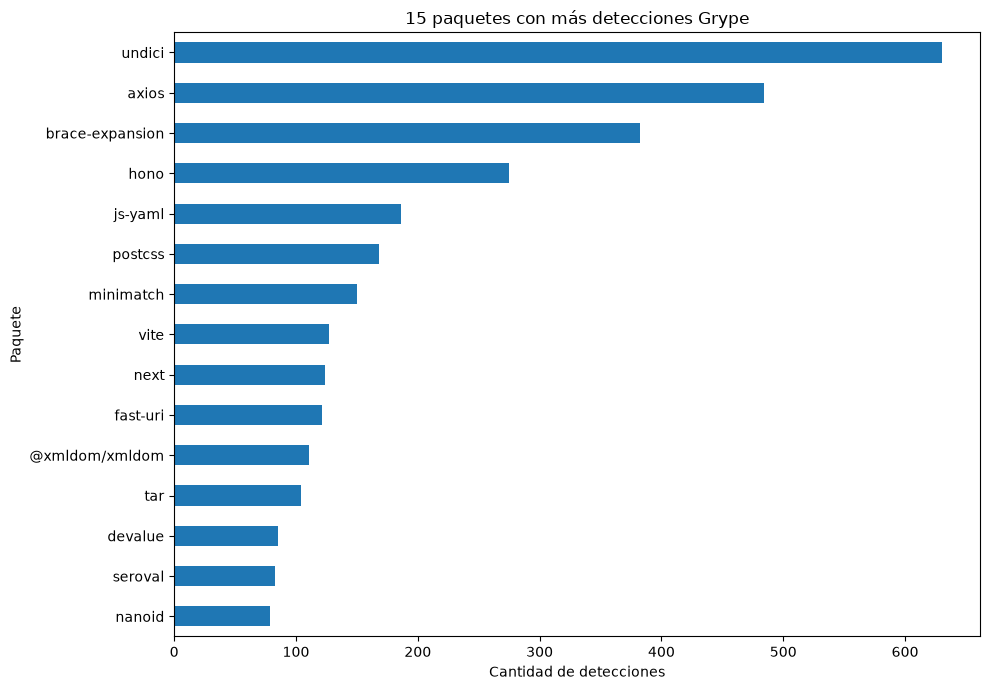

In [24]:
grype_packages.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("15 paquetes con más detecciones Grype")
plt.xlabel("Cantidad de detecciones")
plt.ylabel("Paquete")
plt.tight_layout()
plt.show()


## 15. Grype — repositorios con más vulnerabilidades

In [25]:
grype_by_repo = df_grype["repository"].value_counts()

grype_by_repo.head(15)


repository
TanStack/db              619
TanStack/devtools        441
TanStack/router          392
TanStack/form            314
TanStack/query           302
TanStack/react-charts    291
TanStack/ai              273
TanStack/cli             244
TanStack/virtual         239
TanStack/store           229
TanStack/tanstack.com    196
TanStack/workflow        184
TanStack/alt-cli         179
TanStack/persist         176
TanStack/select          161
Name: count, dtype: int64

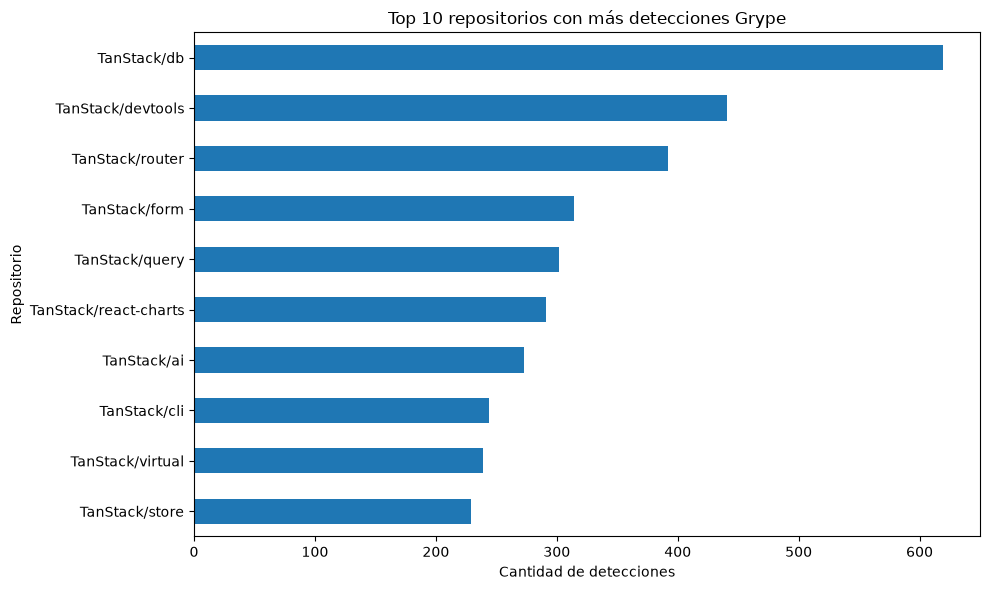

In [26]:
grype_by_repo.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 repositorios con más detecciones Grype")
plt.xlabel("Cantidad de detecciones")
plt.ylabel("Repositorio")
plt.tight_layout()
plt.show()


## 16. Grype — vulnerabilidades únicas

In [27]:
unique_vulnerabilities = df_grype["vulnerability_type"].nunique()
unique_packages = df_grype["package"].nunique()

print("Vulnerabilidades únicas:", unique_vulnerabilities)
print("Paquetes afectados únicos:", unique_packages)


Vulnerabilidades únicas: 736
Paquetes afectados únicos: 216


## 17. Grype — versiones instaladas y corregidas

In [28]:
fixed_available = df_grype["fixed_version"].notna() & df_grype["fixed_version"].astype(str).str.strip().ne("")

fixed_summary = pd.Series({
    "con_version_corregida": int(fixed_available.sum()),
    "sin_version_corregida": int((~fixed_available).sum())
})

fixed_summary


con_version_corregida    5085
sin_version_corregida     101
dtype: int64

In [29]:
fixed_percentage = fixed_available.mean() * 100 if len(df_grype) else 0

print(f"Detecciones con versión corregida disponible: {fixed_percentage:.2f}%")


Detecciones con versión corregida disponible: 98.05%


## 18. Grype — versiones con mayor exposición

In [30]:
package_version_exposure = (
    df_grype.groupby(["package", "version"], dropna=False)
    .size()
    .rename("detections")
    .reset_index()
    .sort_values("detections", ascending=False)
)

package_version_exposure.head(25)


,package,version,detections
589,undici,7.24.4,126
152,axios,1.18.1,108
149,axios,1.15.0,108
147,axios,1.13.2,105
298,hono,4.12.9,93
265,fast-uri,3.1.0,72
592,undici,7.24.8,63
327,js-yaml,4.1.1,60
179,brace-expansion,2.0.2,56
135,@xmldom/xmldom,0.9.10,52


## 19. Grype — severidad por repositorio

In [31]:
grype_repo_severity = pd.crosstab(
    df_grype["repository"],
    df_grype["severity"]
)

grype_repo_severity["total"] = grype_repo_severity.sum(axis=1)

grype_repo_severity.sort_values("total", ascending=False).head(15)


severity,Critical,High,Low,Medium,total
repository,,,,,
TanStack/db,25,308,48,238,619
TanStack/devtools,11,205,32,193,441
TanStack/router,12,179,36,165,392
TanStack/form,13,144,23,134,314
TanStack/query,12,132,21,137,302
TanStack/react-charts,30,117,30,114,291
TanStack/ai,8,142,20,103,273
TanStack/cli,6,124,15,99,244
TanStack/virtual,7,115,10,107,239


## 20. Índice simple de priorización Grype

In [32]:
severity_weights = {
    "Critical": 4,
    "High": 3,
    "Medium": 2,
    "Low": 1,
    "Negligible": 0.5,
    "Unknown": 0
}

df_grype["severity_weight"] = (
    df_grype["severity"]
    .map(severity_weights)
    .fillna(0)
)

repo_grype_priority = (
    df_grype.groupby("repository")
    .agg(
        detections=("vulnerability_type", "size"),
        unique_vulnerabilities=("vulnerability_type", "nunique"),
        affected_packages=("package", "nunique"),
        priority_score=("severity_weight", "sum")
    )
    .sort_values("priority_score", ascending=False)
)

repo_grype_priority.head(15)


,detections,unique_vulnerabilities,affected_packages,priority_score
repository,,,,
TanStack/db,619,326,84,1548.0
TanStack/devtools,441,296,78,1077.0
TanStack/router,392,272,79,951.0
TanStack/form,314,221,67,775.0
TanStack/query,302,231,59,739.0
TanStack/react-charts,291,168,77,729.0
TanStack/ai,273,210,67,684.0
TanStack/cli,244,162,43,609.0
TanStack/virtual,239,193,60,597.0


El `priority_score` es una métrica interna de priorización y no una métrica estándar. Se usa solo para comparar repositorios ponderando severidades.

## 21. Relación entre CodeQL y Grype por repositorio

In [33]:
repo_integrated = pd.DataFrame(index=sorted(set(df_all["repository"].dropna())))

repo_integrated["codeql_findings"] = codeql_by_repo
repo_integrated["grype_detections"] = grype_by_repo

repo_integrated = repo_integrated.fillna(0).astype(int)

repo_integrated["total_security_evidence"] = (
    repo_integrated["codeql_findings"]
    + repo_integrated["grype_detections"]
)

repo_integrated.sort_values(
    "total_security_evidence",
    ascending=False
).head(15)


,codeql_findings,grype_detections,total_security_evidence
TanStack/router,660,392,1052
TanStack/db,84,619,703
TanStack/form,263,314,577
TanStack/devtools,14,441,455
TanStack/ai,159,273,432
TanStack/query,102,302,404
TanStack/cli,68,244,312
TanStack/react-charts,12,291,303
TanStack/tanstack.com,86,196,282
TanStack/container,217,37,254


Esta comparación muestra que un repositorio puede destacar por problemas de código, por vulnerabilidades de dependencias, o por ambas fuentes. No deben sumarse conceptualmente como si fueran el mismo tipo de hallazgo, pero sí pueden compararse como evidencia complementaria.

## 22. Concentración de Grype

In [34]:
grype_concentration = pd.DataFrame({
    "detections": grype_by_repo
})

grype_concentration["percentage"] = (
    grype_concentration["detections"]
    / grype_concentration["detections"].sum()
    * 100
).round(2)

grype_concentration["cumulative_percentage"] = (
    grype_concentration["percentage"]
    .cumsum()
    .round(2)
)

grype_concentration.head(15)


,detections,percentage,cumulative_percentage
repository,,,
TanStack/db,619,11.94,11.94
TanStack/devtools,441,8.50,20.44
TanStack/router,392,7.56,28.00
TanStack/form,314,6.05,34.05
TanStack/query,302,5.82,39.87
TanStack/react-charts,291,5.61,45.48
TanStack/ai,273,5.26,50.74
TanStack/cli,244,4.70,55.44
TanStack/virtual,239,4.61,60.05


In [35]:
top3_grype_share = (
    grype_by_repo.head(3).sum() / len(df_grype) * 100
    if len(df_grype) else 0
)

top5_grype_share = (
    grype_by_repo.head(5).sum() / len(df_grype) * 100
    if len(df_grype) else 0
)

print(f"Top 3 repositorios: {top3_grype_share:.2f}%")
print(f"Top 5 repositorios: {top5_grype_share:.2f}%")


Top 3 repositorios: 28.00%
Top 5 repositorios: 39.88%


## 23. Conclusiones automáticas

In [36]:
codeql_count = len(df_codeql)
grype_count = len(df_grype)
total_count = len(df_all)

codeql_pct = codeql_count / total_count * 100 if total_count else 0
grype_pct = grype_count / total_count * 100 if total_count else 0

critical_count = int((df_grype["severity"] == "Critical").sum())
high_count = int((df_grype["severity"] == "High").sum())

top_grype_repo = grype_by_repo.index[0] if not grype_by_repo.empty else "N/A"
top_grype_repo_count = int(grype_by_repo.iloc[0]) if not grype_by_repo.empty else 0

top_package = grype_packages.index[0] if not grype_packages.empty else "N/A"
top_package_count = int(grype_packages.iloc[0]) if not grype_packages.empty else 0

top_codeql_repo = codeql_by_repo.index[0] if not codeql_by_repo.empty else "N/A"
top_codeql_repo_count = int(codeql_by_repo.iloc[0]) if not codeql_by_repo.empty else 0

text = (
    "### Principales observaciones\n\n"
    f"- El dataset integrado contiene **{total_count} hallazgos**.\n"
    f"- **{codeql_count} ({codeql_pct:.2f}%)** corresponden a CodeQL.\n"
    f"- **{grype_count} ({grype_pct:.2f}%)** corresponden a Grype.\n"
    f"- Grype identificó **{critical_count} detecciones Critical** y **{high_count} High**.\n"
    f"- Se observaron **{unique_vulnerabilities} vulnerabilidades Grype únicas** en **{unique_packages} paquetes afectados**.\n"
    f"- **{fixed_percentage:.2f}%** de las detecciones Grype presentan una versión corregida disponible.\n"
    f"- El repositorio con más detecciones Grype es **`{top_grype_repo}`**, con **{top_grype_repo_count}**.\n"
    f"- El paquete con más detecciones Grype es **`{top_package}`**, con **{top_package_count}**.\n"
    f"- El repositorio con más hallazgos CodeQL es **`{top_codeql_repo}`**, con **{top_codeql_repo_count}**.\n"
    f"- Los tres repositorios con más detecciones Grype concentran **{top3_grype_share:.2f}%** del total de Grype.\n\n"
    
)

display(Markdown(text))


### Principales observaciones

- El dataset integrado contiene **7361 hallazgos**.
- **2175 (29.55%)** corresponden a CodeQL.
- **5186 (70.45%)** corresponden a Grype.
- Grype identificó **183 detecciones Critical** y **2395 High**.
- Se observaron **736 vulnerabilidades Grype únicas** en **216 paquetes afectados**.
- **98.05%** de las detecciones Grype presentan una versión corregida disponible.
- El repositorio con más detecciones Grype es **`TanStack/db`**, con **619**.
- El paquete con más detecciones Grype es **`undici`**, con **630**.
- El repositorio con más hallazgos CodeQL es **`TanStack/router`**, con **660**.
- Los tres repositorios con más detecciones Grype concentran **28.00%** del total de Grype.



## 24. Exportación de resultados

In [37]:
import os

OUTPUT_DIR = Path(os.environ.get("ANALYZER_OUTPUT_DIR", "../output"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df_all.to_csv(
    OUTPUT_DIR / "integrated_findings.csv",
    index=False
)

df_codeql.to_csv(
    OUTPUT_DIR / "codeql_findings.csv",
    index=False
)

df_grype.to_csv(
    OUTPUT_DIR / "grype_findings.csv",
    index=False
)

repo_integrated.reset_index().rename(
    columns={"index": "repository"}
).to_csv(
    OUTPUT_DIR / "repository_integrated_summary.csv",
    index=False
)

repo_grype_priority.reset_index().to_csv(
    OUTPUT_DIR / "grype_repository_priority.csv",
    index=False
)

grype_concentration.reset_index().to_csv(
    OUTPUT_DIR / "grype_concentration.csv",
    index=False
)

grype_severity_summary.reset_index().rename(
    columns={"index": "severity"}
).to_json(
    OUTPUT_DIR / "grype_severity_summary.json",
    orient="records",
    indent=2
)

repo_integrated.reset_index().rename(
    columns={"index": "repository"}
).to_json(
    OUTPUT_DIR / "repository_integrated_summary.json",
    orient="records",
    indent=2
)

print("Resultados exportados en:", OUTPUT_DIR.resolve())

Resultados exportados en: /workspaces/dev-container-test/deliverables/analyzer/output


## 25. Conclusión metodológica

El `results.json` integrado permite analizar en un mismo dataset dos dimensiones distintas de seguridad:

- **CodeQL** entrega evidencia sobre problemas identificados en el código fuente.
- **Grype** entrega evidencia sobre vulnerabilidades conocidas en dependencias y componentes.

Ambas fuentes deben interpretarse por separado antes de compararse, porque miden fenómenos distintos.

El Analyzer debe buscar no solo conteos, sino también:

- diferencias entre repositorios;
- concentración de hallazgos;
- severidades;
- tipos de vulnerabilidad;
- paquetes recurrentemente afectados;
- disponibilidad de versiones corregidas;
- relaciones entre evidencia de código y evidencia de dependencias.

